In [4]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=3, n_informative = 2, n_redundant = 0, random_state=808)
X.shape

(1000, 3)

In [5]:
X

array([[-0.58137777, -0.86840212, -1.34852769],
       [-1.21975466,  2.44172009, -0.74263573],
       [ 2.37167277, -1.44835256, -2.09710184],
       ...,
       [-0.85222274,  0.68051446,  0.84563733],
       [ 0.16643001, -0.47600681, -0.80245798],
       [ 1.05013979, -0.71413134, -0.92471106]], shape=(1000, 3))

/tmp/ipykernel_5202/3953836443.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


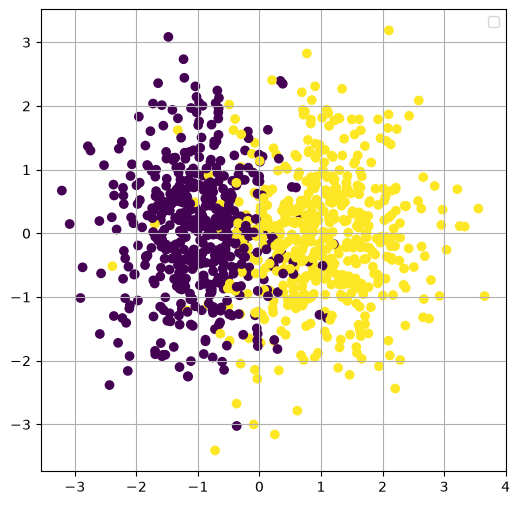

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:, 0], X[:, 1], c=y)
plt.grid()
plt.legend()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [8]:
from sklearn.linear_model import LogisticRegression

# initialisation et entraînement en une ligne
clf = LogisticRegression(random_state=0).fit(X_train, y_train)

print(f"Score de la classification R^2: ", clf.score(X_test, y_test))

Score de la classification R^2:  0.93


<Axes: ylabel='Count'>

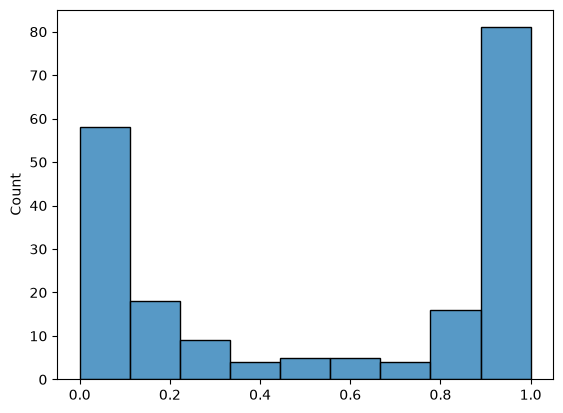

In [9]:
y_hat_proba = clf.predict_proba(X_test)[:,1]
import seaborn as sns
sns.histplot(y_hat_proba)

In [10]:
y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score
print("accuracy",accuracy_score(y_test, y_pred))


accuracy 0.93


In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[ 81,   5],
       [  9, 105]])

In [12]:
y_pred_03 = [ 0 if value < 0.3 else 1 for value in y_hat_proba ]
y_pred_07 = [ 0 if value < 0.7 else 1 for value in y_hat_proba ]

In [13]:
confusion_matrix(y_test, y_pred_03)

array([[ 72,  14],
       [  7, 107]])

In [14]:
confusion_matrix(y_test, y_pred_07)

array([[86,  0],
       [16, 98]])

In [15]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

Precision: 0.9545454545454546
Recall: 0.9210526315789473
ROC-AUC 0.9701142390860873


Text(0.5, 1.0, 'ROC curve')

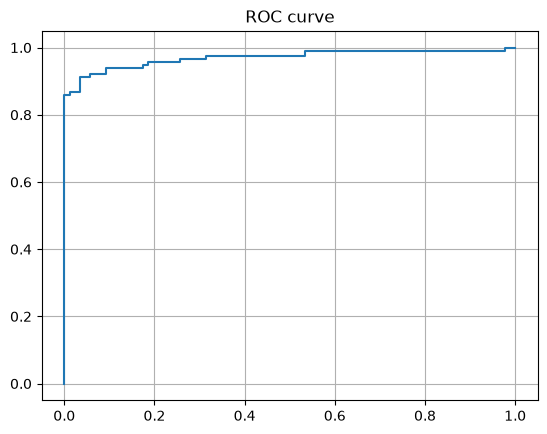

In [16]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.grid()
plt.title("ROC curve")

In [17]:
from sklearn.datasets import make_circles

In [18]:
data = make_circles(n_samples=1000, factor=0.5, noise=0.05)

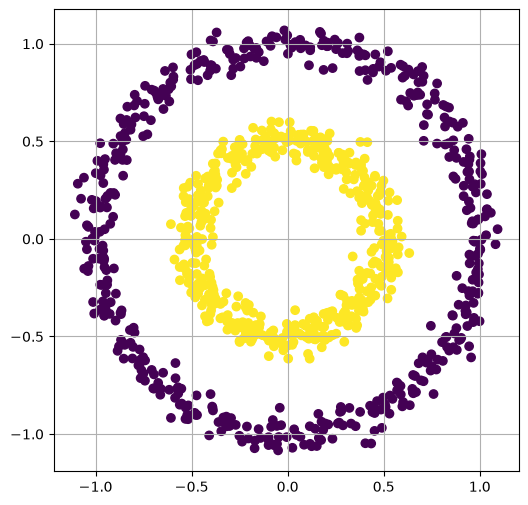

In [ ]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(data[0][:, 0], data[0][:, 1], c=data[1])
plt.grid()
plt.show()

In [19]:
X = data[0]
y = data[1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
clf = LogisticRegression(random_state=0).fit(X_train, y_train)
print(f"Score de la classification R^2: ", clf.score(X_test, y_test))

Score de la classification R^2:  0.48


<Axes: ylabel='Count'>

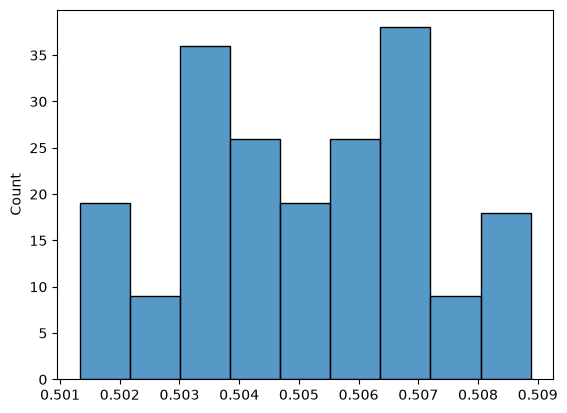

In [20]:
y_hat_proba = clf.predict_proba(X_test)[:,1]
import seaborn as sns
sns.histplot(y_hat_proba)

Text(0.5, 1.0, 'classification')

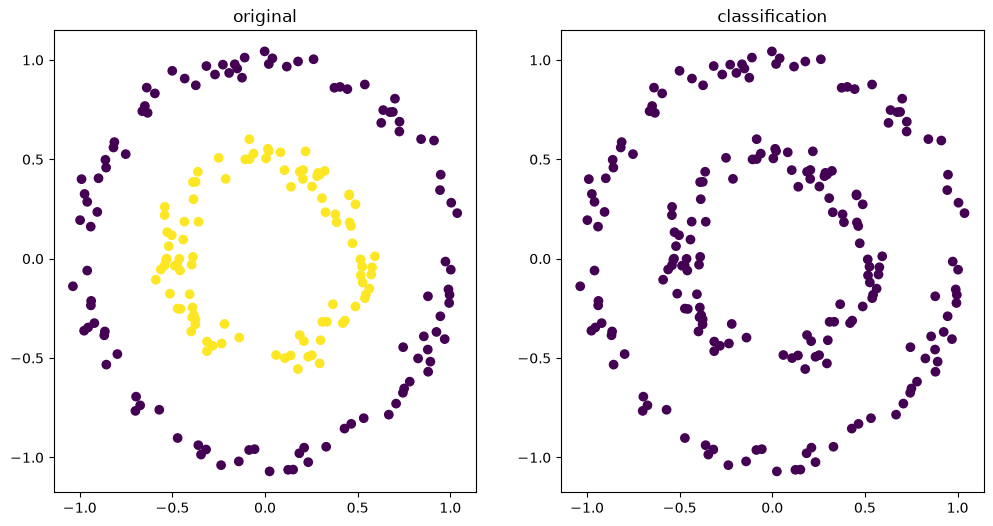

In [25]:
fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
ax.set_title('original')

# 
y_pred = clf.predict(X_test)
ax = fig.add_subplot(1, 2, 2)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
ax.set_title('classification')



In [21]:
y_pred = clf.predict(X_test)
print("accuracy",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

accuracy 0.48
Precision: 0.48
Recall: 1.0
ROC-AUC 0.48217147435897434


Text(0.5, 1.0, 'ROC curve')

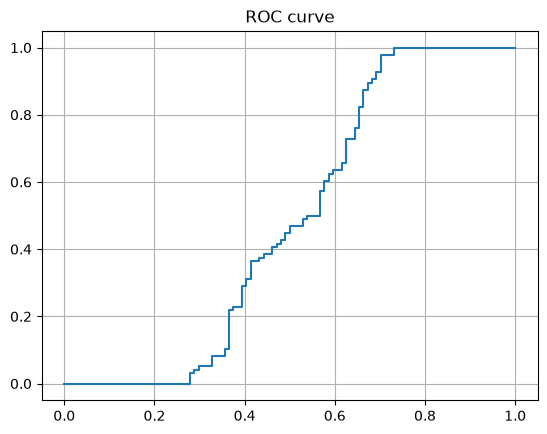

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.grid()
plt.title("ROC curve")

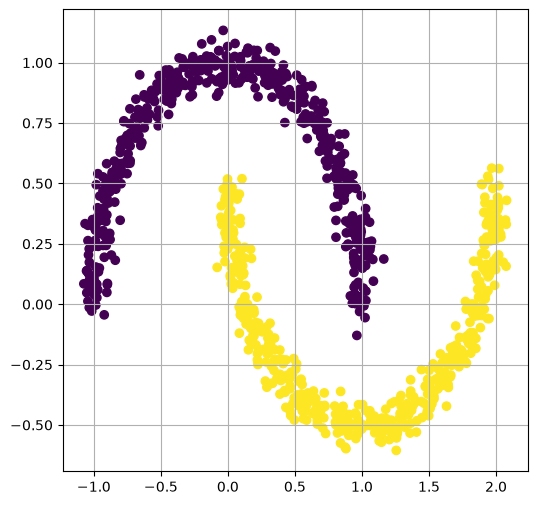

In [24]:
from sklearn.datasets import make_moons
X_moon, y_moon = make_moons(n_samples=1000,  noise=0.05, random_state=0)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon)
plt.grid()
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_moon, y_moon, random_state=0)

clf = LogisticRegression(random_state = 0).fit(X_train,y_train)

print(f"Score de la classification R^2 sur les moons: ", clf.score(X_test, y_test))



Score de la classification R^2 sur les moons:  0.888


Text(0.5, 1.0, 'classification')

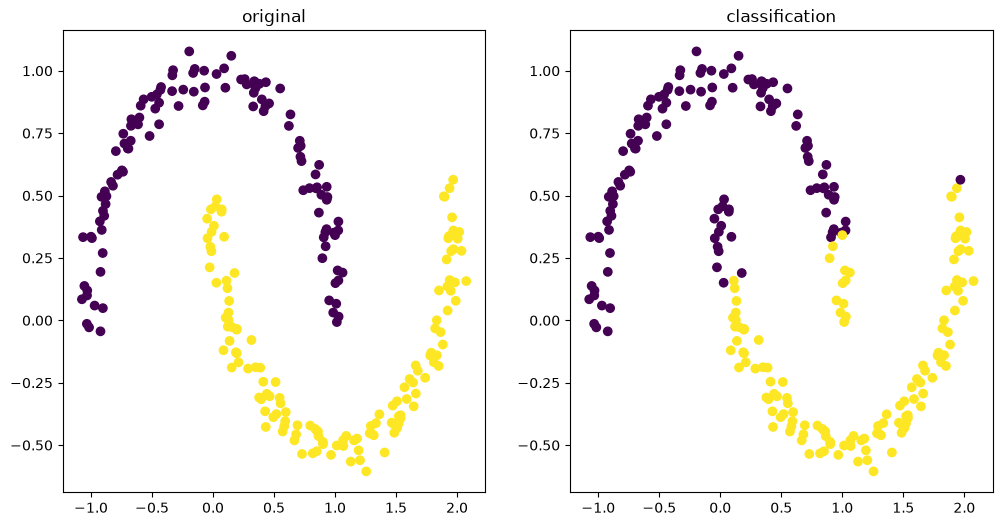

In [27]:
fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
ax.set_title('original')

# 
y_pred = clf.predict(X_test)
ax = fig.add_subplot(1, 2, 2)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
ax.set_title('classification')